# Supervised Deep Learning for Seismic Resolution Enhancement

This notebook builds a complete supervised workflow for temporal resolution enhancement using the reflectivity patches stored in:

- **File:** `SWAN_random_resolution.npz`
- **Key:** `patches`
- **Expected shape:** `(n_samples, 1024, 64)`

Each patch is interpreted as a 2D reflectivity image with `nt=1024` time samples and `nx=64` traces.

## Core idea

Let:

- `r(t,x)` be a reflectivity patch,
- `w_L(t)` be a low-frequency wavelet,
- `w_H(t)` be a high-frequency wavelet.

Then the paired supervised samples are generated as

$$
y_L(t,x) = (w_L * r)(t,x),
$$

$$
y_H(t,x) = (w_H * r)(t,x),
$$

where `*` denotes 1D convolution along time for each trace.

The learning objective is

$$
f_\theta: y_L \mapsto y_H,
$$

with parameters found by minimizing

$$
\min_\theta \frac{1}{N}\sum_{i=1}^N \mathcal{L}(f_\theta(y_L^{(i)}), y_H^{(i)}).
$$

This notebook includes:

- configurable author-defined low/high wavelet frequencies,
- dataset loading from the SWAN NPZ file,
- synthetic pair generation,
- train/validation/test split,
- a compact residual U-Net,
- mixed loss with gradient sharpening,
- training, validation, testing,
- professional visualizations and interpretation notes.

In [1]:
# 1. Configuration

from dataclasses import dataclass
from pathlib import Path

@dataclass
class Config:
    # data
    npz_path: str = "../dataset/SWAN_random_resolution.npz"
    npz_key: str = "patches"
    transpose_patches: bool = False   # True if stored as (n, nx, nt)
    max_samples: int | None = None    # None means use all samples

    # acquisition / wavelets
    dt: float = 0.002
    dx: float = 25.0
    low_freq_hz: float = 12.0
    high_freq_hz: float = 30.0
    wavelet_length_s: float = 0.192

    # data split
    train_ratio: float = 0.70
    val_ratio: float = 0.15
    test_ratio: float = 0.15
    seed: int = 2026

    # normalization
    normalize_mode: str = "per-sample"   # "per-sample", "global", "none"
    eps: float = 1e-8

    # training
    device: str = "cuda"
    batch_size: int = 8
    num_epochs: int = 20
    learning_rate: float = 1e-3
    weight_decay: float = 1e-6

    # loss weights
    lambda_l1: float = 0.70
    lambda_l2: float = 0.25
    lambda_grad: float = 0.05

    # model
    base_channels: int = 16
    use_residual_learning: bool = True

    # outputs
    out_dir: str = "resolution_enhancement_outputs"
    save_best_model: bool = True

cfg = Config()
cfg

Config(npz_path='../dataset/SWAN_random_resolution.npz', npz_key='patches', transpose_patches=False, max_samples=None, dt=0.002, dx=25.0, low_freq_hz=12.0, high_freq_hz=30.0, wavelet_length_s=0.192, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=2026, normalize_mode='per-sample', eps=1e-08, device='cuda', batch_size=8, num_epochs=20, learning_rate=0.001, weight_decay=1e-06, lambda_l1=0.7, lambda_l2=0.25, lambda_grad=0.05, base_channels=16, use_residual_learning=True, out_dir='resolution_enhancement_outputs', save_best_model=True)

In [2]:
# 2. Imports and environment

import os
import time
import math
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

def set_seed(seed: int = 2026):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(cfg.seed)

if cfg.device == "cuda" and not torch.cuda.is_available():
    cfg.device = "cpu"
device = torch.device(cfg.device)

out_dir = Path(cfg.out_dir)
out_dir.mkdir(parents=True, exist_ok=True)

print("Using device:", device)
print("Output directory:", out_dir.resolve())

Using device: cpu
Output directory: /Users/chenyk/xinyue-SWAN/notebooks/resolution_enhancement_outputs


## Utility functions

For a Ricker wavelet with dominant frequency $f_0$,

$$
w(t)=\left(1-2\pi^2 f_0^2 t^2\right)e^{-\pi^2 f_0^2 t^2}.
$$

This wavelet is used to generate the low-resolution and high-resolution seismic patches from the same reflectivity image.

In [3]:
# 3. Utilities

def ricker(f0: float, dt: float, length_s: float = 0.192):
    n = int(round(length_s / dt))
    if n % 2 == 0:
        n += 1
    t = (np.arange(n) - n // 2) * dt
    pf2 = (np.pi * f0 * t) ** 2
    w = (1.0 - 2.0 * pf2) * np.exp(-pf2)
    return t.astype(np.float32), w.astype(np.float32)

def conv_time_traces(reflectivity: np.ndarray, wavelet: np.ndarray) -> np.ndarray:
    # reflectivity shape: (nt, nx)
    nt, nx = reflectivity.shape
    out = np.zeros_like(reflectivity, dtype=np.float32)
    for ix in range(nx):
        out[:, ix] = np.convolve(reflectivity[:, ix], wavelet, mode="same")
    return out

def amplitude_spectrum(signal_1d: np.ndarray, dt: float):
    spec = np.fft.rfft(signal_1d)
    freq = np.fft.rfftfreq(signal_1d.size, d=dt)
    amp = np.abs(spec)
    return freq, amp

def snr_db(reference: np.ndarray, estimate: np.ndarray, eps: float = 1e-12) -> float:
    num = np.sum(reference ** 2)
    den = np.sum((reference - estimate) ** 2) + eps
    return float(10.0 * np.log10(num / den + eps))

def psnr_db(reference: np.ndarray, estimate: np.ndarray, eps: float = 1e-12) -> float:
    mse = np.mean((reference - estimate) ** 2)
    peak = np.max(np.abs(reference)) + eps
    return float(20.0 * np.log10(peak / np.sqrt(mse + eps)))

def relative_l2(reference: np.ndarray, estimate: np.ndarray, eps: float = 1e-12) -> float:
    return float(np.linalg.norm(reference - estimate) / (np.linalg.norm(reference) + eps))

def temporal_gradient(x: torch.Tensor) -> torch.Tensor:
    return x[:, :, 1:, :] - x[:, :, :-1, :]

def plot_patch(ax, data, dt=0.002, dx=25.0, title="", cmap="gray", percentile=99.0):
    vmax = np.percentile(np.abs(data), percentile)
    im = ax.imshow(
        data,
        cmap=cmap,
        aspect="auto",
        origin="upper",
        extent=[0, data.shape[1] * dx, data.shape[0] * dt, 0],
        vmin=-vmax,
        vmax=vmax,
    )
    ax.set_title(title)
    ax.set_xlabel("Distance / trace axis")
    ax.set_ylabel("Time (s)")
    return im

def plot_trace_overlay(ax, ref, inp, pred=None, title="Trace comparison"):
    ax.plot(ref, label="Target (high-res)", linewidth=2)
    ax.plot(inp, label="Input (low-res)", linewidth=1.5)
    if pred is not None:
        ax.plot(pred, label="Prediction", linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel("Time sample")
    ax.set_ylabel("Amplitude")
    ax.legend()
    ax.grid(True, alpha=0.3)

## Load the SWAN reflectivity patches

Expected data layout:

```python
data = np.load("SWAN_random_resolution.npz")
patches = data["patches"]
```

with shape `(n_samples, 1024, 64)`.

In [4]:
# 4. Load NPZ data

npz_path = Path(cfg.npz_path)
if not npz_path.exists():
    raise FileNotFoundError(
        f"Cannot find {npz_path.resolve()}. "
        "Place SWAN_random_resolution.npz next to this notebook or edit cfg.npz_path."
    )

data = np.load(npz_path)
print("Available keys:", list(data.keys()))

if cfg.npz_key not in data:
    raise KeyError(f"Key '{cfg.npz_key}' not found.")

patches = np.asarray(data[cfg.npz_key], dtype=np.float32)

if cfg.max_samples is not None:
    patches = patches[:cfg.max_samples]

if patches.ndim != 3:
    raise ValueError("Expected patches to have 3 dimensions.")

if cfg.transpose_patches:
    patches = np.transpose(patches, (0, 2, 1))

n_samples, nt, nx = patches.shape
print("Using patches shape:", patches.shape)

Available keys: ['patches']
Using patches shape: (1000, 1024, 64)


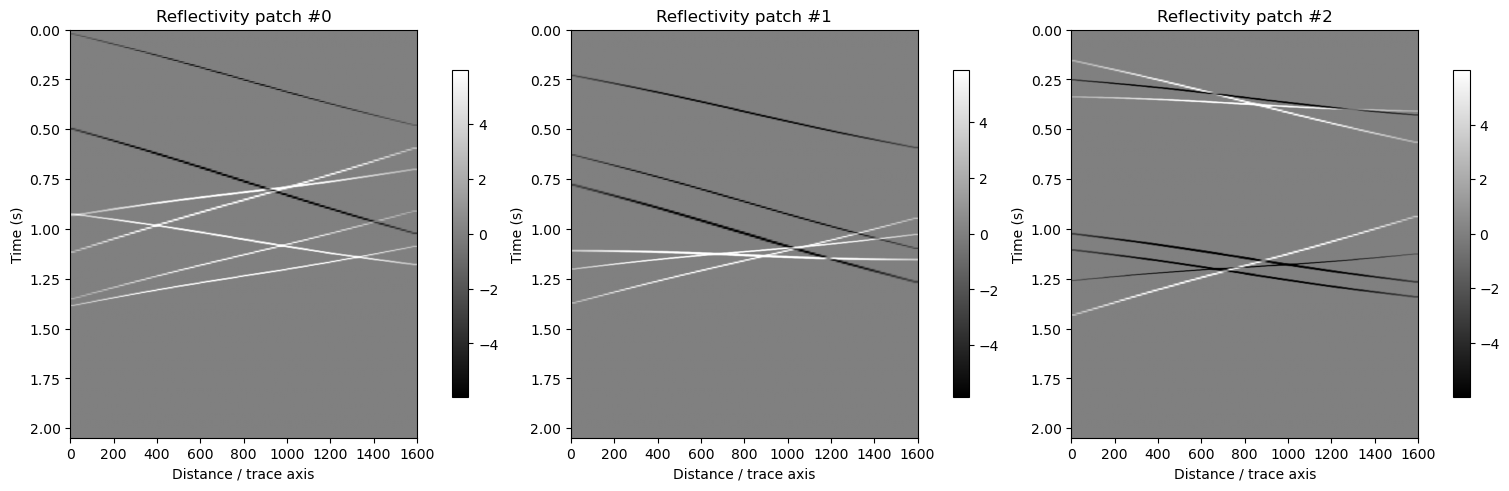

In [5]:
# Quick visualization of reflectivity patches

n_show = min(3, len(patches))
fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 4.8), constrained_layout=True)
if n_show == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    im = plot_patch(ax, patches[i], dt=cfg.dt, dx=cfg.dx, title=f"Reflectivity patch #{i}")
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.show()

## Generate supervised low-resolution / high-resolution pairs

For each reflectivity patch $r_i(t,x)$, define

$$
y_{L,i}(t,x) = (w_L * r_i)(t,x),
\qquad
y_{H,i}(t,x) = (w_H * r_i)(t,x).
$$

The author controls the effective bandwidth through `low_freq_hz` and `high_freq_hz`.

In [6]:
# 5. Create supervised pairs

twL, wL = ricker(cfg.low_freq_hz, cfg.dt, cfg.wavelet_length_s)
twH, wH = ricker(cfg.high_freq_hz, cfg.dt, cfg.wavelet_length_s)

inputs_lr = np.zeros_like(patches, dtype=np.float32)
targets_hr = np.zeros_like(patches, dtype=np.float32)

for i in range(n_samples):
    inputs_lr[i] = conv_time_traces(patches[i], wL)
    targets_hr[i] = conv_time_traces(patches[i], wH)

print("inputs_lr shape :", inputs_lr.shape)
print("targets_hr shape:", targets_hr.shape)

inputs_lr shape : (1000, 1024, 64)
targets_hr shape: (1000, 1024, 64)


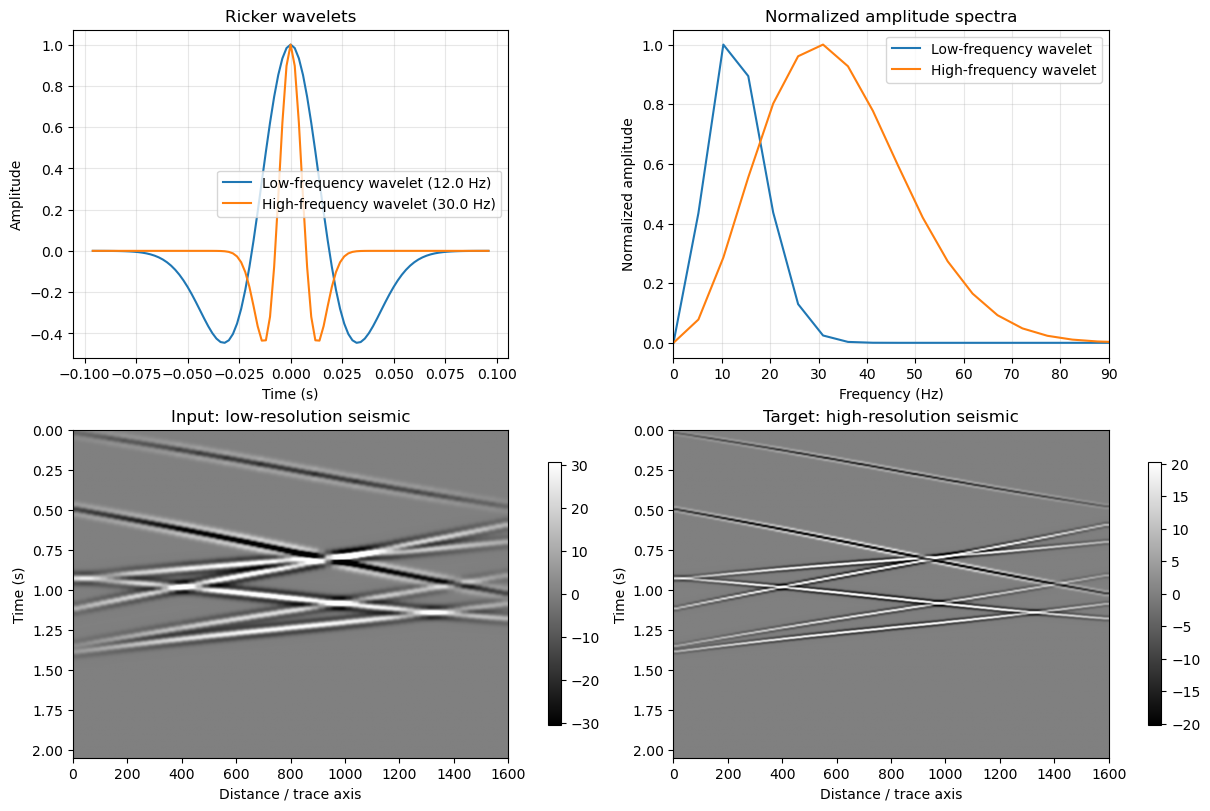

In [7]:
# Wavelet and data-pair illustrations

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

axes[0, 0].plot(twL, wL, label=f"Low-frequency wavelet ({cfg.low_freq_hz:.1f} Hz)")
axes[0, 0].plot(twH, wH, label=f"High-frequency wavelet ({cfg.high_freq_hz:.1f} Hz)")
axes[0, 0].set_title("Ricker wavelets")
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

fL, aL = amplitude_spectrum(wL, cfg.dt)
fH, aH = amplitude_spectrum(wH, cfg.dt)
axes[0, 1].plot(fL, aL / (aL.max() + 1e-12), label="Low-frequency wavelet")
axes[0, 1].plot(fH, aH / (aH.max() + 1e-12), label="High-frequency wavelet")
axes[0, 1].set_xlim(0, max(80, cfg.high_freq_hz * 3))
axes[0, 1].set_title("Normalized amplitude spectra")
axes[0, 1].set_xlabel("Frequency (Hz)")
axes[0, 1].set_ylabel("Normalized amplitude")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

idx = 0
im0 = plot_patch(axes[1, 0], inputs_lr[idx], dt=cfg.dt, dx=cfg.dx, title="Input: low-resolution seismic")
plt.colorbar(im0, ax=axes[1, 0], shrink=0.8)

im1 = plot_patch(axes[1, 1], targets_hr[idx], dt=cfg.dt, dx=cfg.dx, title="Target: high-resolution seismic")
plt.colorbar(im1, ax=axes[1, 1], shrink=0.8)

plt.show()

## Normalization

This notebook supports:

- **per-sample** normalization,
- **global** normalization,
- **no normalization**.

Per-sample normalization is often a practical default when the emphasis is on waveform shape and relative sharpening.

In [8]:
# 6. Normalization

def normalize_pair(x: np.ndarray, y: np.ndarray, mode: str = "per-sample", eps: float = 1e-8):
    if mode == "none":
        scales = np.ones((x.shape[0],), dtype=np.float32)
        return x.astype(np.float32), y.astype(np.float32), scales

    if mode == "global":
        scale = max(np.max(np.abs(x)), np.max(np.abs(y)), eps)
        scales = np.full((x.shape[0],), scale, dtype=np.float32)
        return (x / scale).astype(np.float32), (y / scale).astype(np.float32), scales

    if mode == "per-sample":
        scales = np.maximum(
            np.max(np.abs(np.stack([x, y], axis=1)), axis=(1, 2, 3)),
            eps
        ).astype(np.float32)
        x_n = x / scales[:, None, None]
        y_n = y / scales[:, None, None]
        return x_n.astype(np.float32), y_n.astype(np.float32), scales

    raise ValueError(f"Unknown normalize_mode: {mode}")

X, Y, scales = normalize_pair(inputs_lr, targets_hr, cfg.normalize_mode, cfg.eps)

# add channel dimension: (N, 1, nt, nx)
X = X[:, None, :, :]
Y = Y[:, None, :, :]

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Normalization mode:", cfg.normalize_mode)

X shape: (1000, 1, 1024, 64)
Y shape: (1000, 1, 1024, 64)
Normalization mode: per-sample


## Dataset and split

In [9]:
# 7. Dataset and dataloaders

class SeismicResolutionDataset(Dataset):
    def __init__(self, x: np.ndarray, y: np.ndarray):
        self.x = torch.from_numpy(x).float()
        self.y = torch.from_numpy(y).float()

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

dataset = SeismicResolutionDataset(X, Y)

total_ratio = cfg.train_ratio + cfg.val_ratio + cfg.test_ratio
if not np.isclose(total_ratio, 1.0):
    raise ValueError("train_ratio + val_ratio + test_ratio must sum to 1.")

n_total = len(dataset)
n_train = int(round(n_total * cfg.train_ratio))
n_val = int(round(n_total * cfg.val_ratio))
n_test = n_total - n_train - n_val

generator = torch.Generator().manual_seed(cfg.seed)
train_ds, val_ds, test_ds = random_split(dataset, [n_train, n_val, n_test], generator=generator)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)

print(f"Total samples: {n_total}")
print(f"Train / Val / Test: {len(train_ds)} / {len(val_ds)} / {len(test_ds)}")

Total samples: 1000
Train / Val / Test: 700 / 150 / 150


## Model: residual U-Net

We use a compact 2D U-Net with skip connections.  
The residual formulation is

$$
\hat{y}_H = y_L + g_\theta(y_L),
$$

so the network learns the missing high-resolution correction.

In [10]:
# 8. Residual U-Net

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)

class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = ConvBlock(in_ch, out_ch)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        feat = self.conv(x)
        down = self.pool(feat)
        return feat, down

class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = ConvBlock(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        diff_y = skip.size(2) - x.size(2)
        diff_x = skip.size(3) - x.size(3)
        x = F.pad(x, [diff_x // 2, diff_x - diff_x // 2,
                      diff_y // 2, diff_y - diff_y // 2])
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)

class UNetResolutionEnhancer(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base_ch=16, residual=True):
        super().__init__()
        self.residual = residual

        self.d1 = DownBlock(in_ch, base_ch)
        self.d2 = DownBlock(base_ch, base_ch * 2)
        self.d3 = DownBlock(base_ch * 2, base_ch * 4)
        self.d4 = DownBlock(base_ch * 4, base_ch * 8)

        self.bottleneck = ConvBlock(base_ch * 8, base_ch * 16)

        self.u4 = UpBlock(base_ch * 16, base_ch * 8, base_ch * 8)
        self.u3 = UpBlock(base_ch * 8, base_ch * 4, base_ch * 4)
        self.u2 = UpBlock(base_ch * 4, base_ch * 2, base_ch * 2)
        self.u1 = UpBlock(base_ch * 2, base_ch, base_ch)

        self.out_conv = nn.Conv2d(base_ch, out_ch, kernel_size=1)

    def forward(self, x):
        x_in = x

        s1, x1 = self.d1(x)
        s2, x2 = self.d2(x1)
        s3, x3 = self.d3(x2)
        s4, x4 = self.d4(x3)

        b = self.bottleneck(x4)

        x = self.u4(b, s4)
        x = self.u3(x, s3)
        x = self.u2(x, s2)
        x = self.u1(x, s1)

        out = self.out_conv(x)
        if self.residual:
            out = out + x_in
        return out

model = UNetResolutionEnhancer(
    in_ch=1,
    out_ch=1,
    base_ch=cfg.base_channels,
    residual=cfg.use_residual_learning,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"Trainable parameters: {n_params:,}")

UNetResolutionEnhancer(
  (d1): DownBlock(
    (conv): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): GELU(approximate='none')
      )
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (d2): DownBlock(
    (conv): ConvBlock(
      (block): Sequential(
        (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(

## Loss function

We combine three terms:

1. **L1 reconstruction**
$$
\mathcal{L}_1 = \|\hat{y}_H - y_H\|_1
$$

2. **L2 reconstruction**
$$
\mathcal{L}_2 = \|\hat{y}_H - y_H\|_2^2
$$

3. **Temporal gradient loss**
$$
\mathcal{L}_g = \|\nabla_t \hat{y}_H - \nabla_t y_H\|_1
$$

The total loss is

$$
\mathcal{L}_{\text{total}} =
\lambda_1 \mathcal{L}_1 +
\lambda_2 \mathcal{L}_2 +
\lambda_g \mathcal{L}_g.
$$

The gradient term encourages sharper temporal detail and therefore better effective resolution.

In [11]:
# 9. Loss, optimizer, scheduler

def mixed_resolution_loss(pred: torch.Tensor, target: torch.Tensor,
                          lambda_l1=0.70, lambda_l2=0.25, lambda_grad=0.05):
    l1 = F.l1_loss(pred, target)
    l2 = F.mse_loss(pred, target)
    grad = F.l1_loss(temporal_gradient(pred), temporal_gradient(target))
    total = lambda_l1 * l1 + lambda_l2 * l2 + lambda_grad * grad
    return total, {"l1": l1.item(), "l2": l2.item(), "grad": grad.item()}

optimizer = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
print("Optimizer ready.")

Optimizer ready.


In [12]:
# 10. Training and evaluation loops

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0
    count = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss, parts = mixed_resolution_loss(
            pred, yb,
            lambda_l1=cfg.lambda_l1,
            lambda_l2=cfg.lambda_l2,
            lambda_grad=cfg.lambda_grad,
        )
        loss.backward()
        optimizer.step()

        bs = xb.size(0)
        running_loss += loss.item() * bs
        count += bs

    return running_loss / max(count, 1)

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    running_loss = 0.0
    count = 0

    snr_in_list = []
    snr_out_list = []
    psnr_list = []
    rl2_list = []

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        pred = model(xb)

        loss, _ = mixed_resolution_loss(
            pred, yb,
            lambda_l1=cfg.lambda_l1,
            lambda_l2=cfg.lambda_l2,
            lambda_grad=cfg.lambda_grad,
        )

        bs = xb.size(0)
        running_loss += loss.item() * bs
        count += bs

        x_np = xb.cpu().numpy()
        y_np = yb.cpu().numpy()
        p_np = pred.cpu().numpy()

        for i in range(bs):
            xin = x_np[i, 0]
            ygt = y_np[i, 0]
            ypr = p_np[i, 0]

            snr_in_list.append(snr_db(ygt, xin))
            snr_out_list.append(snr_db(ygt, ypr))
            psnr_list.append(psnr_db(ygt, ypr))
            rl2_list.append(relative_l2(ygt, ypr))

    return {
        "loss": float(running_loss / max(count, 1)),
        "snr_input_mean": float(np.mean(snr_in_list)),
        "snr_output_mean": float(np.mean(snr_out_list)),
        "snr_improvement_mean": float(np.mean(np.array(snr_out_list) - np.array(snr_in_list))),
        "psnr_mean": float(np.mean(psnr_list)),
        "relative_l2_mean": float(np.mean(rl2_list)),
    }

history = {
    "train_loss": [],
    "val_loss": [],
    "val_snr_in": [],
    "val_snr_out": [],
    "val_snr_gain": [],
    "val_psnr": [],
    "val_rl2": [],
}

best_val = np.inf
best_model_path = out_dir / "best_resolution_enhancer.pt"

In [13]:
# 11. Train

start_time = time.time()

for epoch in range(1, cfg.num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_metrics = evaluate(model, val_loader, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_snr_in"].append(val_metrics["snr_input_mean"])
    history["val_snr_out"].append(val_metrics["snr_output_mean"])
    history["val_snr_gain"].append(val_metrics["snr_improvement_mean"])
    history["val_psnr"].append(val_metrics["psnr_mean"])
    history["val_rl2"].append(val_metrics["relative_l2_mean"])

    scheduler.step(val_metrics["loss"])
    lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch:03d}/{cfg.num_epochs:03d} | "
        f"lr={lr:.2e} | "
        f"train_loss={train_loss:.6f} | "
        f"val_loss={val_metrics['loss']:.6f} | "
        f"val_SNR_in={val_metrics['snr_input_mean']:.2f} dB | "
        f"val_SNR_out={val_metrics['snr_output_mean']:.2f} dB | "
        f"gain={val_metrics['snr_improvement_mean']:.2f} dB"
    )

    if cfg.save_best_model and val_metrics["loss"] < best_val:
        best_val = val_metrics["loss"]
        torch.save(model.state_dict(), best_model_path)

elapsed = time.time() - start_time
print(f"Training finished in {elapsed / 60:.2f} minutes.")

if cfg.save_best_model and best_model_path.exists():
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print("Loaded best model:", best_model_path)

Epoch 001/020 | lr=1.00e-03 | train_loss=0.023564 | val_loss=0.012135 | val_SNR_in=-4.34 dB | val_SNR_out=3.46 dB | gain=7.80 dB
Epoch 002/020 | lr=1.00e-03 | train_loss=0.010688 | val_loss=0.010199 | val_SNR_in=-4.34 dB | val_SNR_out=4.77 dB | gain=9.11 dB
Epoch 003/020 | lr=1.00e-03 | train_loss=0.009298 | val_loss=0.007986 | val_SNR_in=-4.34 dB | val_SNR_out=5.40 dB | gain=9.73 dB
Epoch 004/020 | lr=1.00e-03 | train_loss=0.008234 | val_loss=0.006914 | val_SNR_in=-4.34 dB | val_SNR_out=6.91 dB | gain=11.24 dB
Epoch 005/020 | lr=1.00e-03 | train_loss=0.007087 | val_loss=0.007585 | val_SNR_in=-4.34 dB | val_SNR_out=6.39 dB | gain=10.73 dB
Epoch 006/020 | lr=1.00e-03 | train_loss=0.007062 | val_loss=0.007884 | val_SNR_in=-4.34 dB | val_SNR_out=7.00 dB | gain=11.33 dB
Epoch 007/020 | lr=1.00e-03 | train_loss=0.006159 | val_loss=0.004729 | val_SNR_in=-4.34 dB | val_SNR_out=8.66 dB | gain=13.00 dB
Epoch 008/020 | lr=1.00e-03 | train_loss=0.006196 | val_loss=0.005507 | val_SNR_in=-4.34 dB |

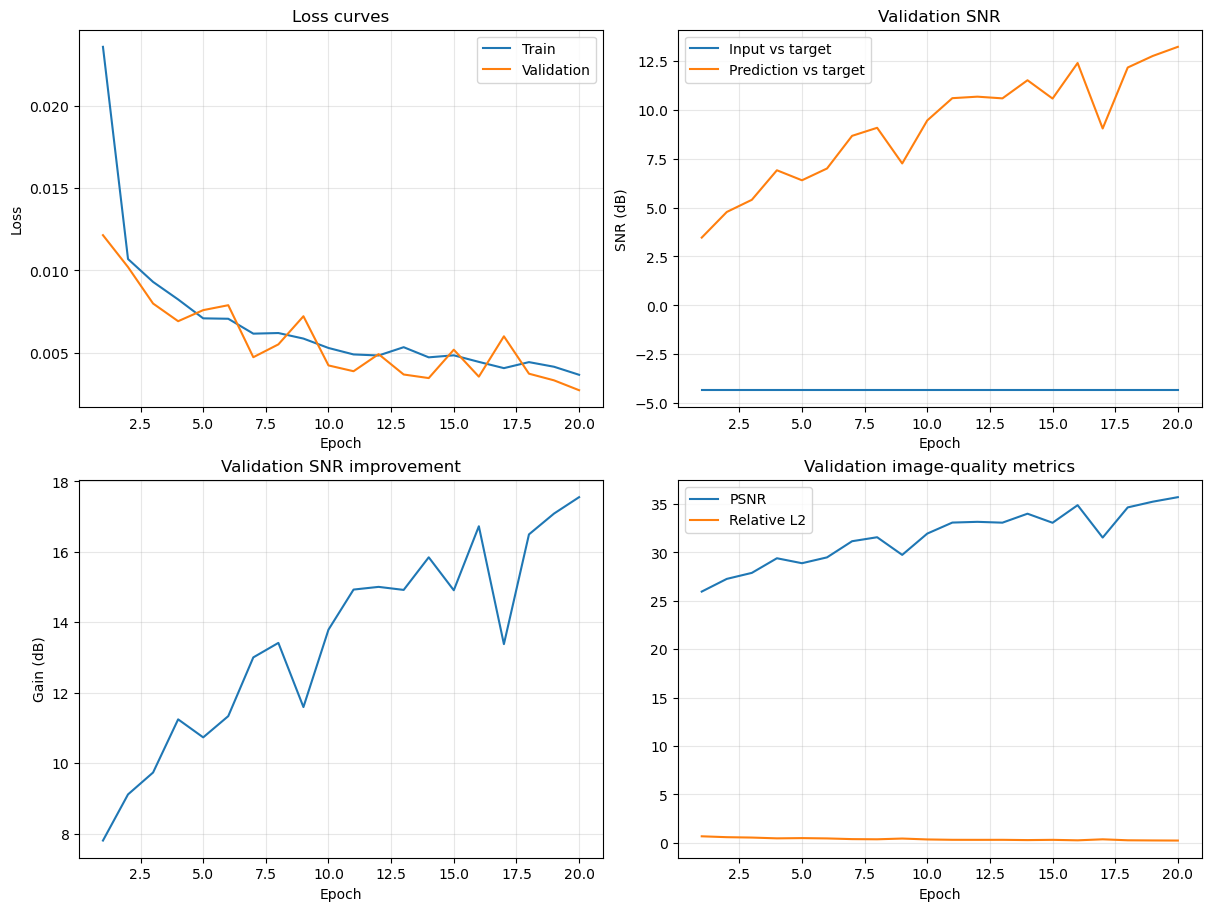

In [14]:
# 12. Training curves

epochs = np.arange(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)

axes[0, 0].plot(epochs, history["train_loss"], label="Train")
axes[0, 0].plot(epochs, history["val_loss"], label="Validation")
axes[0, 0].set_title("Loss curves")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs, history["val_snr_in"], label="Input vs target")
axes[0, 1].plot(epochs, history["val_snr_out"], label="Prediction vs target")
axes[0, 1].set_title("Validation SNR")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("SNR (dB)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(epochs, history["val_snr_gain"])
axes[1, 0].set_title("Validation SNR improvement")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Gain (dB)")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(epochs, history["val_psnr"], label="PSNR")
axes[1, 1].plot(epochs, history["val_rl2"], label="Relative L2")
axes[1, 1].set_title("Validation image-quality metrics")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.show()

## Test-set evaluation

In [15]:
# 13. Final test metrics

test_metrics = evaluate(model, test_loader, device)
print("========== Test Metrics ==========")
for k, v in test_metrics.items():
    print(f"{k:>24s} : {v:.6f}")

========== Test Metrics ==========
                    loss : 0.002778
          snr_input_mean : -4.311098
         snr_output_mean : 12.648209
    snr_improvement_mean : 16.959307
               psnr_mean : 35.309098
        relative_l2_mean : 0.249058


## Visual inspection on test samples

A good result should show:

- sharper temporal wavelets,
- less smearing than the low-resolution input,
- event continuity preserved,
- limited hallucination and artifact generation.

In [16]:
# 14. Collect predictions for visualization

@torch.no_grad()
def collect_predictions(model, loader, device, max_items=4):
    model.eval()
    xs, ys, ps = [], [], []
    for xb, yb in loader:
        pred = model(xb.to(device)).cpu()
        xs.append(xb.cpu())
        ys.append(yb.cpu())
        ps.append(pred)
        if sum(item.shape[0] for item in xs) >= max_items:
            break
    Xc = torch.cat(xs, dim=0)[:max_items].numpy()
    Yc = torch.cat(ys, dim=0)[:max_items].numpy()
    Pc = torch.cat(ps, dim=0)[:max_items].numpy()
    return Xc, Yc, Pc

X_vis, Y_vis, P_vis = collect_predictions(model, test_loader, device, max_items=min(4, len(test_ds)))
print(X_vis.shape, Y_vis.shape, P_vis.shape)

(4, 1, 1024, 64) (4, 1, 1024, 64) (4, 1, 1024, 64)


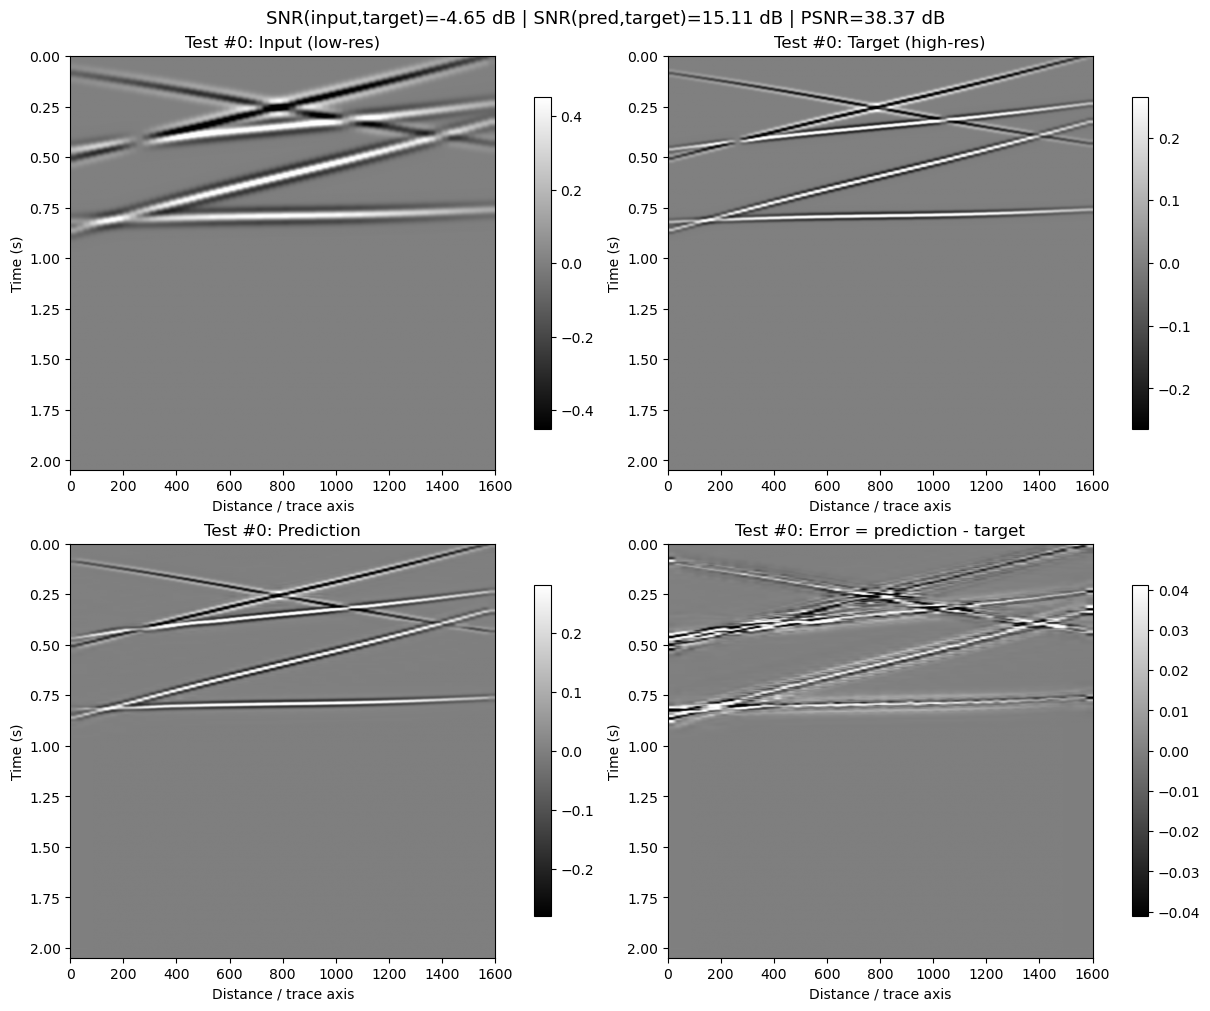

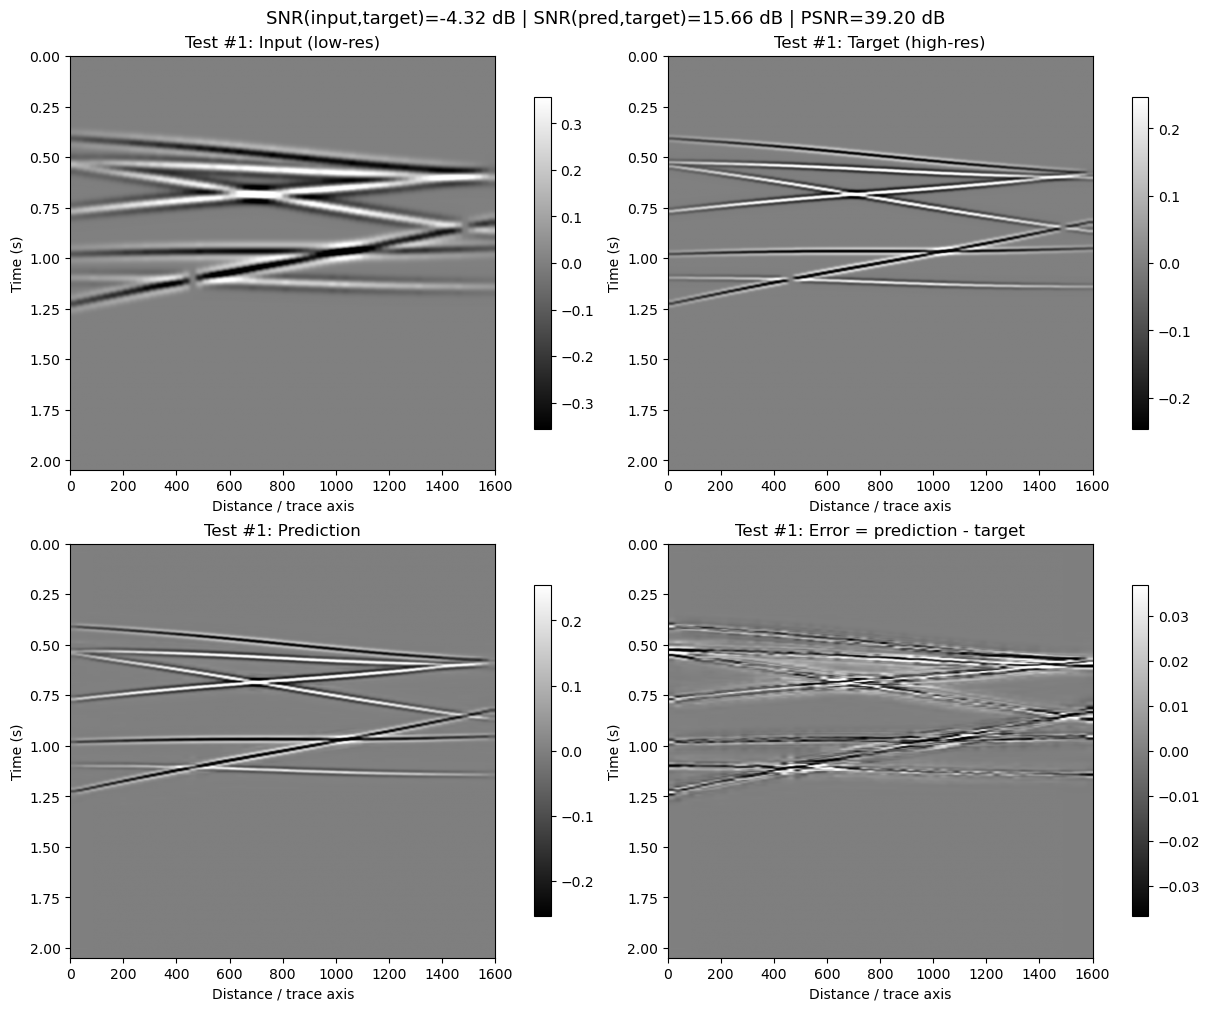

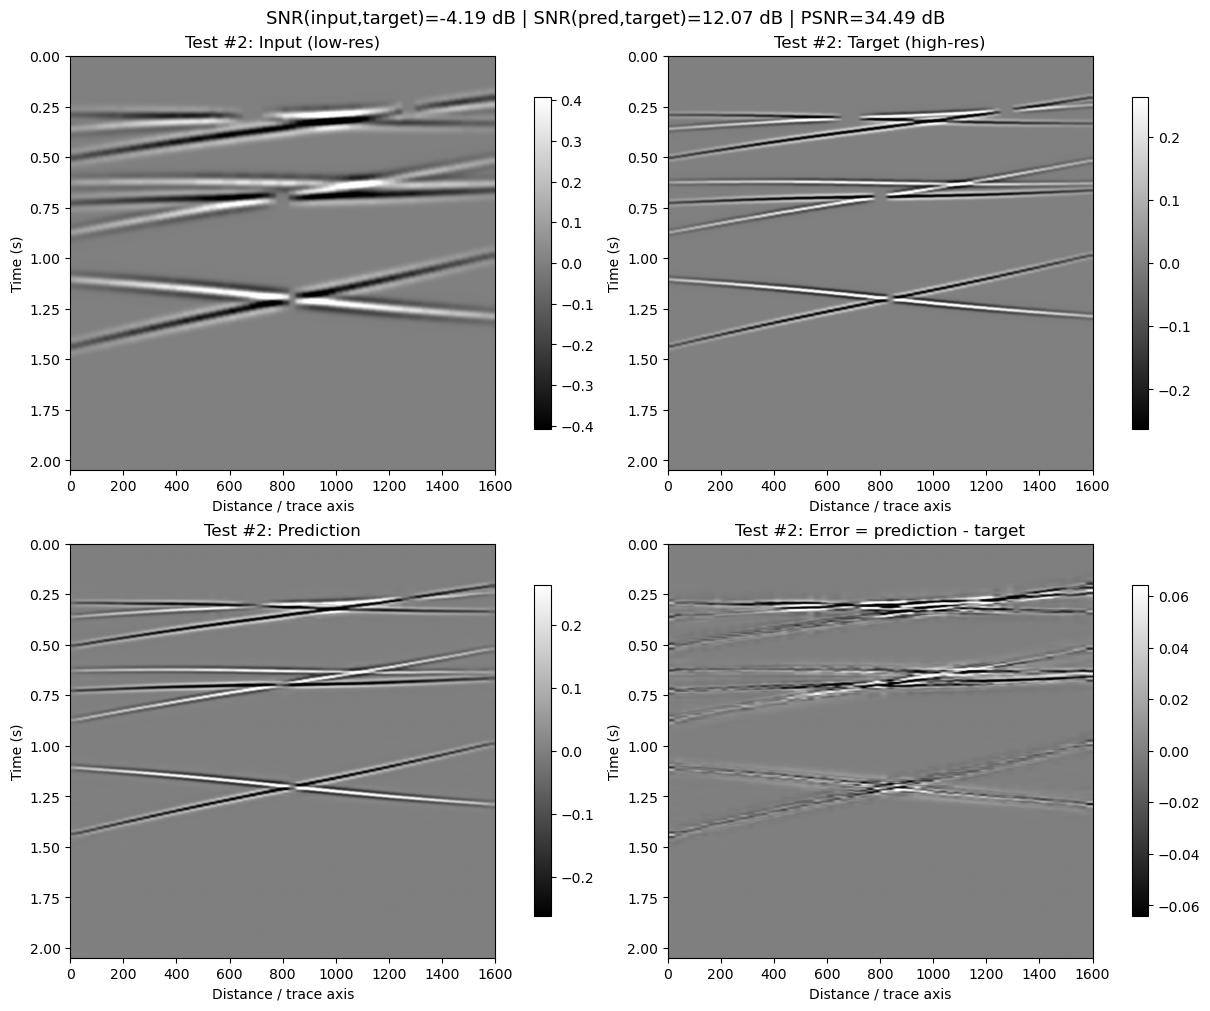

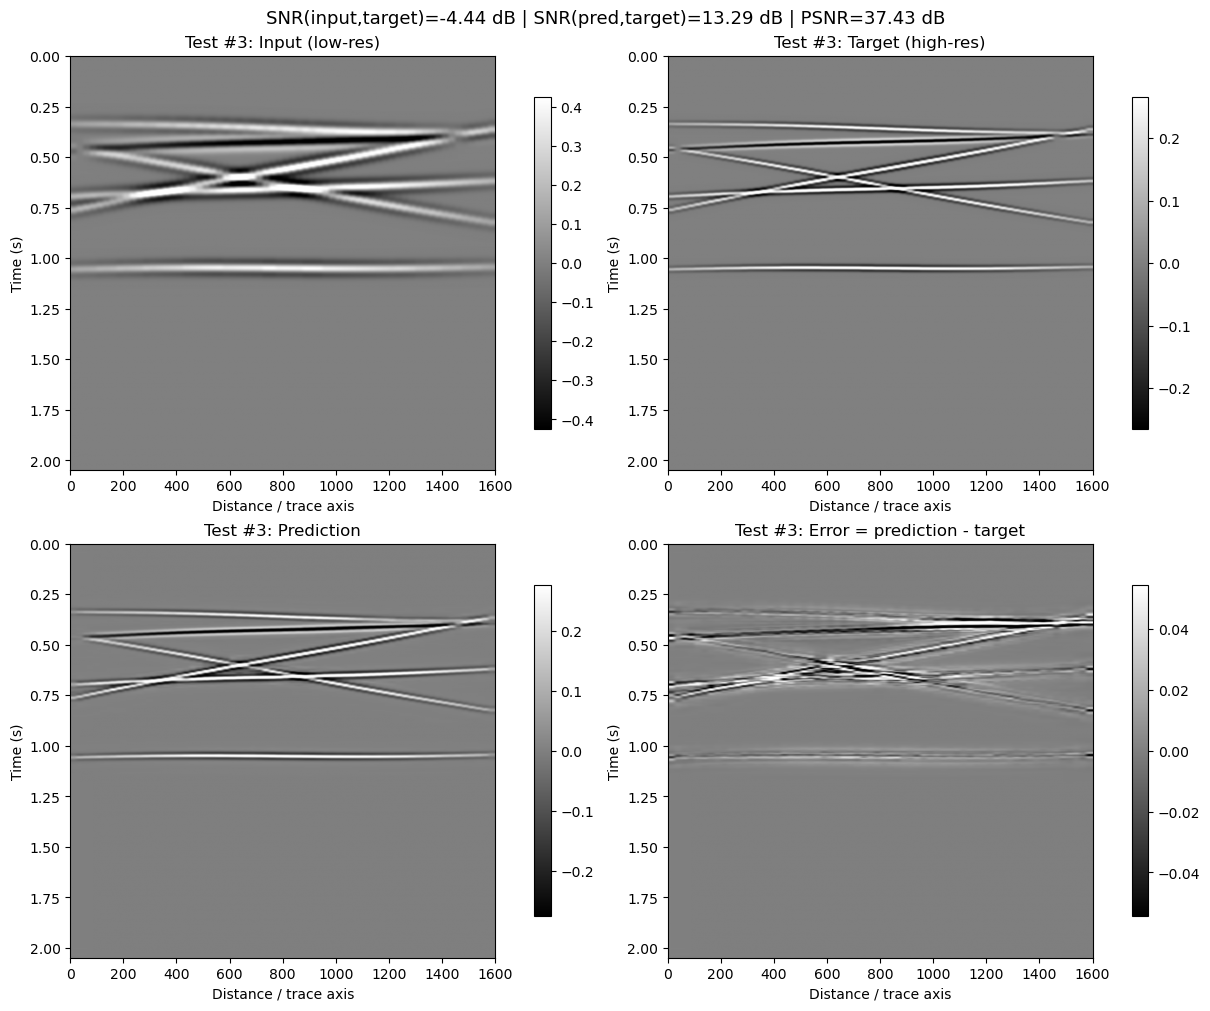

In [17]:
# 15. Image-domain comparisons

for i in range(len(X_vis)):
    x_in = X_vis[i, 0]
    y_gt = Y_vis[i, 0]
    y_pr = P_vis[i, 0]
    err = y_pr - y_gt

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

    im0 = plot_patch(axes[0, 0], x_in, dt=cfg.dt, dx=cfg.dx, title=f"Test #{i}: Input (low-res)")
    plt.colorbar(im0, ax=axes[0, 0], shrink=0.8)

    im1 = plot_patch(axes[0, 1], y_gt, dt=cfg.dt, dx=cfg.dx, title=f"Test #{i}: Target (high-res)")
    plt.colorbar(im1, ax=axes[0, 1], shrink=0.8)

    im2 = plot_patch(axes[1, 0], y_pr, dt=cfg.dt, dx=cfg.dx, title=f"Test #{i}: Prediction")
    plt.colorbar(im2, ax=axes[1, 0], shrink=0.8)

    im3 = plot_patch(axes[1, 1], err, dt=cfg.dt, dx=cfg.dx, title=f"Test #{i}: Error = prediction - target")
    plt.colorbar(im3, ax=axes[1, 1], shrink=0.8)

    fig.suptitle(
        f"SNR(input,target)={snr_db(y_gt, x_in):.2f} dB | "
        f"SNR(pred,target)={snr_db(y_gt, y_pr):.2f} dB | "
        f"PSNR={psnr_db(y_gt, y_pr):.2f} dB",
        fontsize=13
    )
    plt.show()

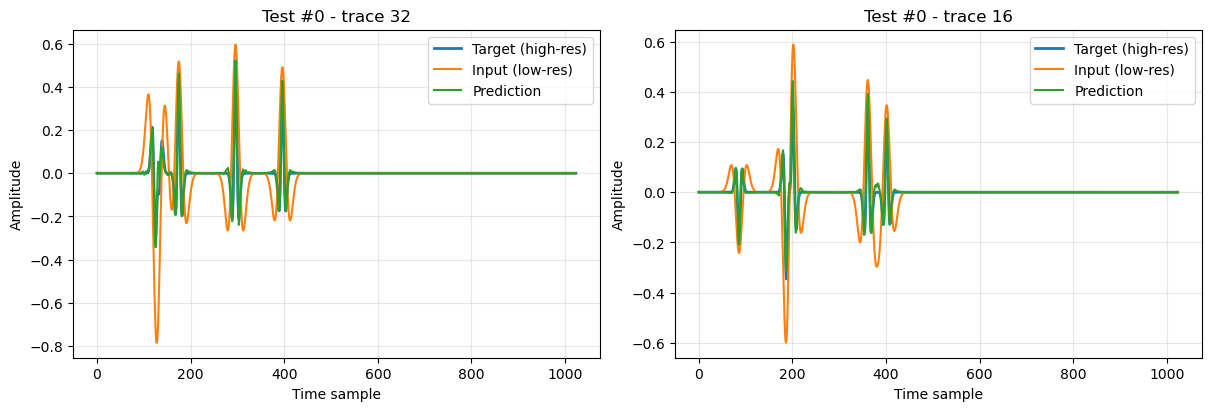

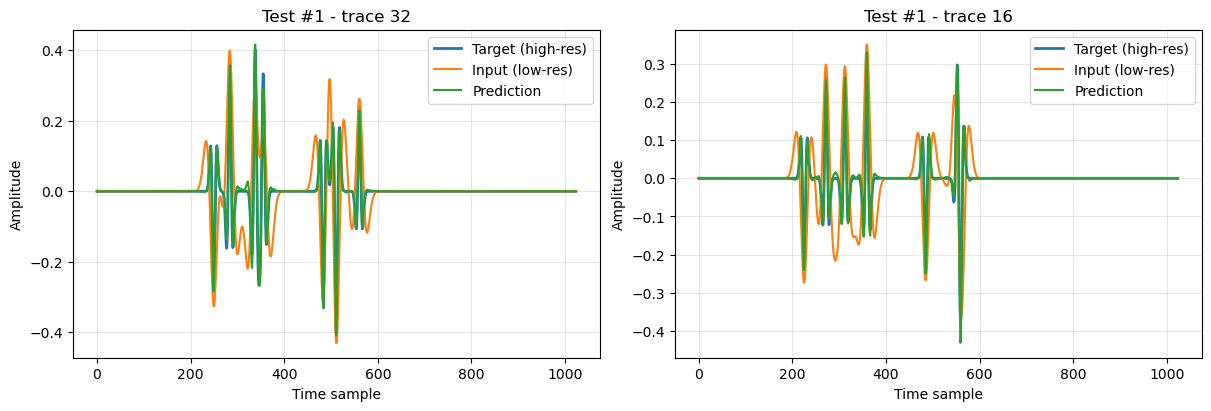

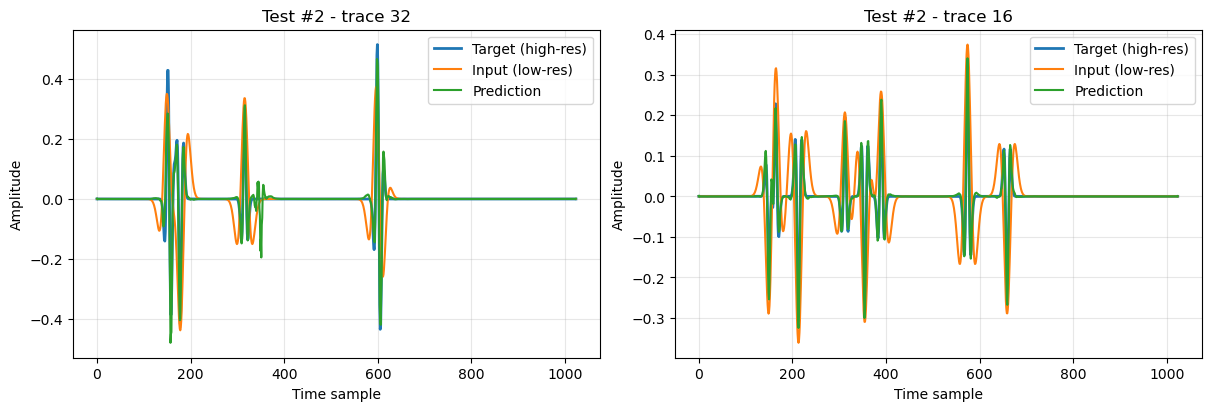

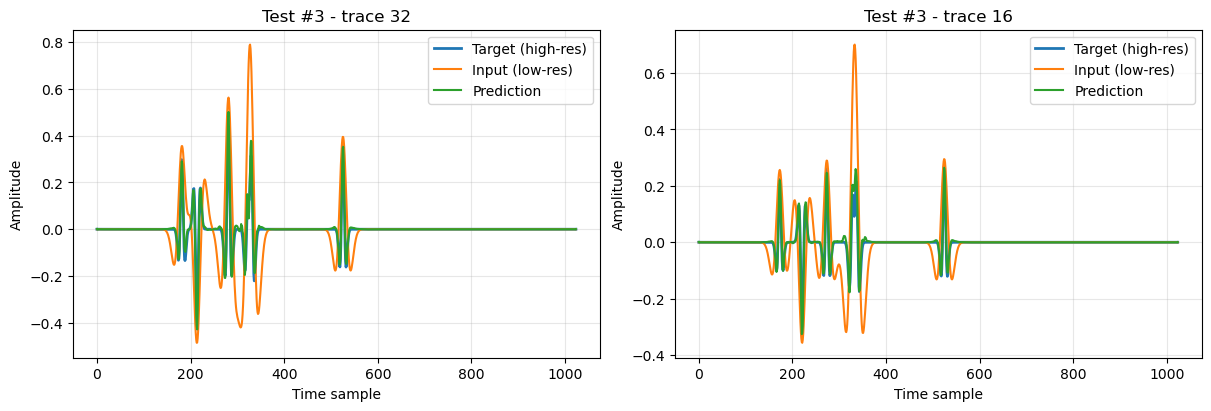

In [18]:
# 16. Trace overlays

for i in range(len(X_vis)):
    x_in = X_vis[i, 0]
    y_gt = Y_vis[i, 0]
    y_pr = P_vis[i, 0]

    trace_ids = [x_in.shape[1] // 2, max(0, x_in.shape[1] // 4)]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    for ax, tr in zip(axes, trace_ids):
        plot_trace_overlay(
            ax,
            ref=y_gt[:, tr],
            inp=x_in[:, tr],
            pred=y_pr[:, tr],
            title=f"Test #{i} - trace {tr}",
        )
    plt.show()

## Spectral comparison on a representative trace

Resolution enhancement is closely related to bandwidth restoration, so it is useful to compare trace spectra.

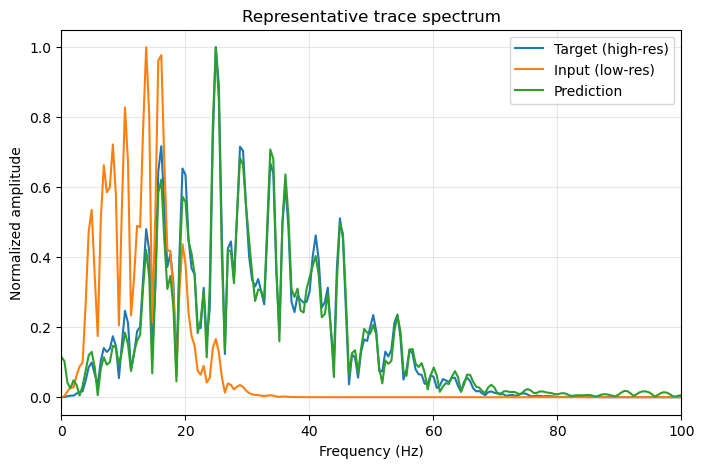

In [19]:
# 17. Spectrum comparison

if len(X_vis) > 0:
    i = 0
    tr = X_vis[i, 0].shape[1] // 2

    trace_in = X_vis[i, 0][:, tr]
    trace_gt = Y_vis[i, 0][:, tr]
    trace_pr = P_vis[i, 0][:, tr]

    f_in, a_in = amplitude_spectrum(trace_in, cfg.dt)
    f_gt, a_gt = amplitude_spectrum(trace_gt, cfg.dt)
    f_pr, a_pr = amplitude_spectrum(trace_pr, cfg.dt)

    plt.figure(figsize=(8, 5))
    plt.plot(f_gt, a_gt / (a_gt.max() + 1e-12), label="Target (high-res)")
    plt.plot(f_in, a_in / (a_in.max() + 1e-12), label="Input (low-res)")
    plt.plot(f_pr, a_pr / (a_pr.max() + 1e-12), label="Prediction")
    plt.xlim(0, max(100, cfg.high_freq_hz * 3))
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Normalized amplitude")
    plt.title("Representative trace spectrum")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [20]:
# 18. Save summary artifacts

history_npz = out_dir / "training_history.npz"
metrics_npz = out_dir / "test_metrics.npz"

np.savez(
    history_npz,
    train_loss=np.array(history["train_loss"]),
    val_loss=np.array(history["val_loss"]),
    val_snr_in=np.array(history["val_snr_in"]),
    val_snr_out=np.array(history["val_snr_out"]),
    val_snr_gain=np.array(history["val_snr_gain"]),
    val_psnr=np.array(history["val_psnr"]),
    val_rl2=np.array(history["val_rl2"]),
)

np.savez(metrics_npz, **{k: np.array(v) for k, v in test_metrics.items()})

if best_model_path.exists():
    print("Saved model   :", best_model_path.resolve())
print("Saved history :", history_npz.resolve())
print("Saved metrics :", metrics_npz.resolve())

Saved model   : /Users/chenyk/xinyue-SWAN/notebooks/resolution_enhancement_outputs/best_resolution_enhancer.pt
Saved history : /Users/chenyk/xinyue-SWAN/notebooks/resolution_enhancement_outputs/training_history.npz
Saved metrics : /Users/chenyk/xinyue-SWAN/notebooks/resolution_enhancement_outputs/test_metrics.npz


# Interpretation and practical notes

## What the model learns

The network does not estimate reflectivity directly.  
It learns a mapping between two seismic bandwidth regimes:

$$
(w_L * r) \longrightarrow (w_H * r).
$$

This is a supervised resolution translation problem.

## Why is it physically meaningful

Because both the input and target are generated from the same underlying reflectivity patch, the network is trained to infer how seismic events should look as the effective wavelet sharpens.

## Important limitation

A network cannot recover an arbitrarily high bandwidth if the input has lost too much information.  
So the output should be interpreted as a learned, data-driven high-resolution estimate constrained by the training set and the chosen bandwidth gap.

## What can you adjust?

- number of patches,
- train/validation/test split,
- low and high wavelet frequencies,
- wavelet length and sampling interval,
- normalization strategy,
- architecture and parameter count,
- optimizer / learning rate / epochs / batch size,
- evaluation metrics,
- representative visual examples.

## Homework?

1. Change the wavelet pair, such as 10 Hz -> 25 Hz, 12 Hz -> 30 Hz, or 15 Hz -> 40 Hz.
2. Add controlled noise to the low-resolution input and evaluate robustness.
3. Compare U-Net against a shallow CNN or residual CNN.
4. Compare L1 only versus mixed losses.
5. Study generalization across different frequency gaps.

